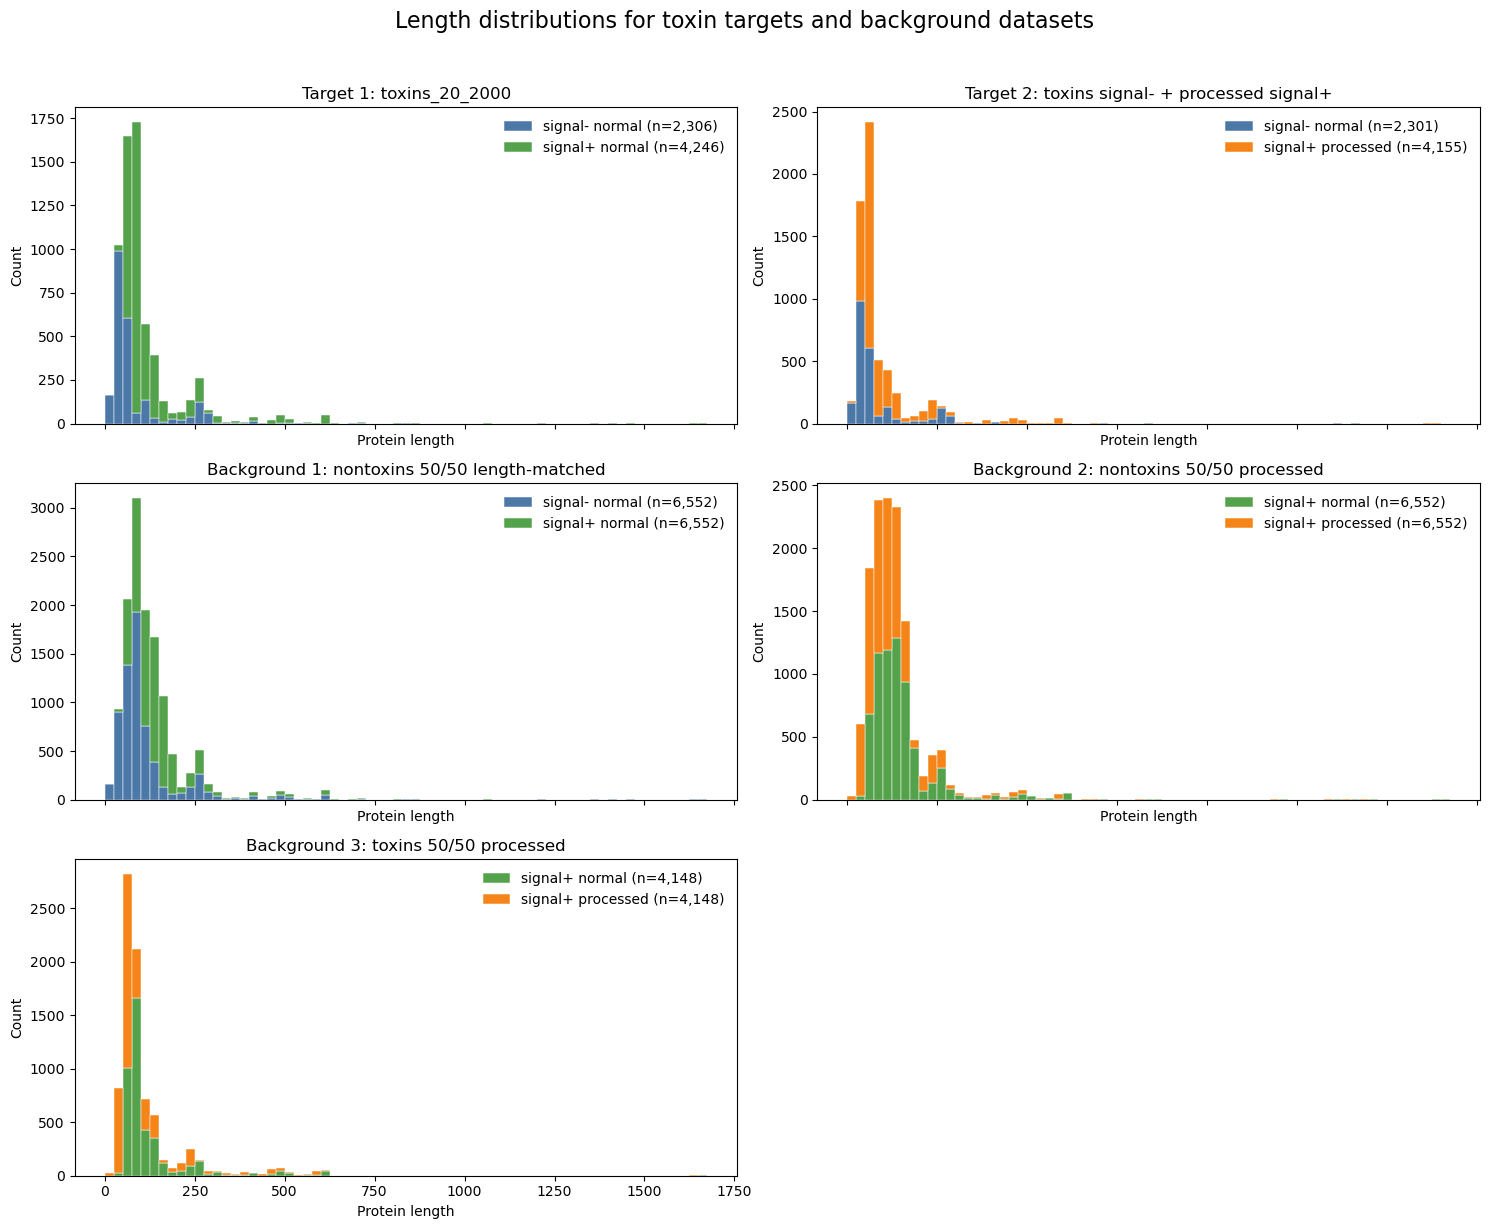

n  min  \
dataset                                      category                       
Background 1: nontoxins 50/50 length-matched signal+ normal     6552   25   
                                             signal- normal     6552   20   
Background 2: nontoxins 50/50 processed      signal+ normal     6552   25   
                                             signal+ processed  6552    9   
Background 3: toxins 50/50 processed         signal+ normal     4148   28   
                                             signal+ processed  4148    4   
Target 1: toxins_20_2000                     signal+ normal     4246   28   
                                             signal- normal     2306   20   
Target 2: toxins signal- + processed signal+ signal+ processed  4155    4   
                                             signal- normal     2301   20   

                                                                median   mean  \
dataset                                      category                           
Background 1: nontoxins 50/50 length-matched signal+ normal      129.0  150.7   
                                             signal- normal       87.0  116.9   
Background 2: nontoxins 50/50 processed      signal+ normal      129.0  150.7   
                                             signal+ processed   107.0  128.6   
Background 3: toxins 50/50 processed         signal+ normal       85.0  125.5   
                                             signal+ processed    64.0  104.8   
Target 1: toxins_20_2000                     signal+ normal       85.0  128.8   
                                             signal- normal       50.0   85.8   
Target 2: toxins signal- + processed signal+ signal+ processed    64.0  104.9   
                                             signal- normal       50.0   85.8   

                                                                 max  
dataset                                      category                 
Background 1: nontoxins 50/50 length-matched signal+ normal     1651  
                                             signal- normal     1652  
Background 2: nontoxins 50/50 processed      signal+ normal     1651  
                                             signal+ processed  1636  
Background 3: toxins 50/50 processed         signal+ normal     1652  
                                             signal+ processed  1630  
Target 1: toxins_20_2000                     signal+ normal     1652  
                                             signal- normal     1413  
Target 2: toxins signal- + processed signal+ signal+ processed  1630  
                                             signal- normal     1413

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Works whether the notebook is launched from the repository root or PP_project/.
cwd = Path.cwd()
project_dir = cwd if (cwd / "datasets").exists() else cwd / "PP_project"
datasets_dir = project_dir / "datasets"

datasets = [
    {
        "label": "Target 1: toxins_20_2000",
        "file": "toxins_20_2000.tsv",
        "signal_source": "toxins_20_2000.tsv",
        "mode": "signal_status",
    },
    {
        "label": "Target 2: toxins signal- + processed signal+",
        "file": "toxins_20_2000_signal_processed_puls_nonsignal.tsv",
        "signal_source": "toxins_20_2000.tsv",
        # This metadata file kept original entry IDs for processed signal+ toxins,
        # so infer processed-vs-normal from the original Signal peptide column.
        "mode": "signal_positive_is_processed",
    },
    {
        "label": "Background 1: nontoxins 50/50 length-matched",
        "file": "nontoxins_20_2000_5050_lengthmatched.tsv",
        "signal_source": "nontoxins_20_2000.tsv",
        "mode": "signal_status",
    },
    {
        "label": "Background 2: nontoxins 50/50 processed",
        "file": "nontoxins_20_2000_5050_processed.tsv",
        "signal_source": "nontoxins_20_2000.tsv",
        "mode": "processed_suffix",
    },
    {
        "label": "Background 3: toxins 50/50 processed",
        "file": "toxins_20_2000_5050_processed.tsv",
        "signal_source": "toxins_20_2000.tsv",
        "mode": "processed_suffix",
    },
]


def normalized_columns(df: pd.DataFrame) -> dict[str, str]:
    return {column.lower(): column for column in df.columns}


def base_entry(entry: object) -> str:
    return str(entry).removesuffix("_processed")


def read_signal_status(filename: str) -> dict[str, bool]:
    path = datasets_dir / filename
    df = pd.read_csv(path, sep="\t")
    columns = normalized_columns(df)
    entry_col = columns.get("entry")
    signal_col = columns.get("signal peptide")
    if entry_col is None or signal_col is None:
        raise ValueError(f"{path} must contain Entry and Signal peptide columns")

    signal_values = df[signal_col].fillna("").astype(str).str.strip()
    return dict(zip(df[entry_col].astype(str), signal_values.ne(""), strict=False))


signal_status_by_file = {
    filename: read_signal_status(filename)
    for filename in {dataset["signal_source"] for dataset in datasets}
}


def classify_entry(entry: object, signal_status: bool, mode: str) -> str:
    is_processed_suffix = str(entry).endswith("_processed")

    if mode == "signal_positive_is_processed":
        return "signal+ processed" if signal_status else "signal- normal"

    if mode == "processed_suffix" and is_processed_suffix:
        return "signal+ processed" if signal_status else "signal- processed"

    return "signal+ normal" if signal_status else "signal- normal"


def read_lengths(dataset: dict[str, str]) -> pd.DataFrame:
    path = datasets_dir / dataset["file"]
    df = pd.read_csv(path, sep="\t")
    columns = normalized_columns(df)
    entry_col = columns.get("entry")
    length_col = columns.get("length")
    if entry_col is None or length_col is None:
        raise ValueError(f"{path} must contain Entry/entry and Length/length columns")

    out = df[[entry_col, length_col]].rename(
        columns={entry_col: "entry", length_col: "length"}
    )
    signal_lookup = signal_status_by_file[dataset["signal_source"]]
    out["dataset"] = dataset["label"]
    out["base_entry"] = out["entry"].map(base_entry)
    out["has_signal_peptide"] = out["base_entry"].map(signal_lookup).fillna(False)
    out["category"] = [
        classify_entry(entry, signal_status, dataset["mode"])
        for entry, signal_status in zip(out["entry"], out["has_signal_peptide"], strict=False)
    ]
    out["length"] = pd.to_numeric(out["length"], errors="coerce")
    return out.dropna(subset=["length"])


lengths = pd.concat([read_lengths(dataset) for dataset in datasets], ignore_index=True)

category_order = [
    "signal- normal",
    "signal+ normal",
    "signal+ processed",
    "signal- processed",
]
colors = {
    "signal- normal": "#4C78A8",
    "signal+ normal": "#54A24B",
    "signal+ processed": "#F58518",
    "signal- processed": "#B279A2",
}

bin_width = 25
max_length = int(np.ceil(lengths["length"].max() / bin_width) * bin_width)
bins = np.arange(0, max_length + bin_width, bin_width)

fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True, sharey=False)
axes = axes.ravel()

for ax, dataset in zip(axes, datasets, strict=False):
    subset = lengths[lengths["dataset"] == dataset["label"]]
    present_categories = [
        category for category in category_order if category in set(subset["category"])
    ]
    values = [
        subset.loc[subset["category"] == category, "length"]
        for category in present_categories
    ]

    ax.hist(
        values,
        bins=bins,
        stacked=True,
        label=[
            f"{category} (n={len(vals):,})"
            for category, vals in zip(present_categories, values, strict=False)
        ],
        color=[colors[category] for category in present_categories],
        edgecolor="white",
        linewidth=0.35,
    )
    ax.set_title(dataset["label"])
    ax.set_xlabel("Protein length")
    ax.set_ylabel("Count")
    ax.legend(frameon=False)

for ax in axes[len(datasets):]:
    ax.axis("off")

fig.suptitle(
    "Length distributions for toxin targets and background datasets",
    y=1.02,
    fontsize=16,
)
fig.tight_layout()
plt.show()

summary = (
    lengths.groupby(["dataset", "category"], observed=True)["length"]
    .agg(n="size", min="min", median="median", mean="mean", max="max")
    .round({"median": 1, "mean": 1})
)
display(summary)
